# 6. Deployment

The trained CNN is wrapped in a small REST microservice and intended to live in a Minecraft
server's backend infrastructure. This phase describes the deployment architecture, the API
contract, the operational knobs available to a server admin, and the limitations of the current
artifact.


## 6.1 Deployment scenario

The target environment is a **modded / plugin-enabled Minecraft server** (Spigot, PaperMC, Forge).
These engines expose lifecycle events that a plugin can hook into — in particular, the
[PlayerJoinEvent](https://jd.papermc.io/paper/26.1.2/org/bukkit/event/player/PlayerJoinEvent.html) fires the moment a player connects to the server, *before* their skin is
broadcast to other players. Large Mineacraft-Server Networks already rely on such a custom modded infrastructure or larger backend microservices. Integrating an additional API call to the FastAPI-Service is an easy way to adapt our feature

The deployment flow is:

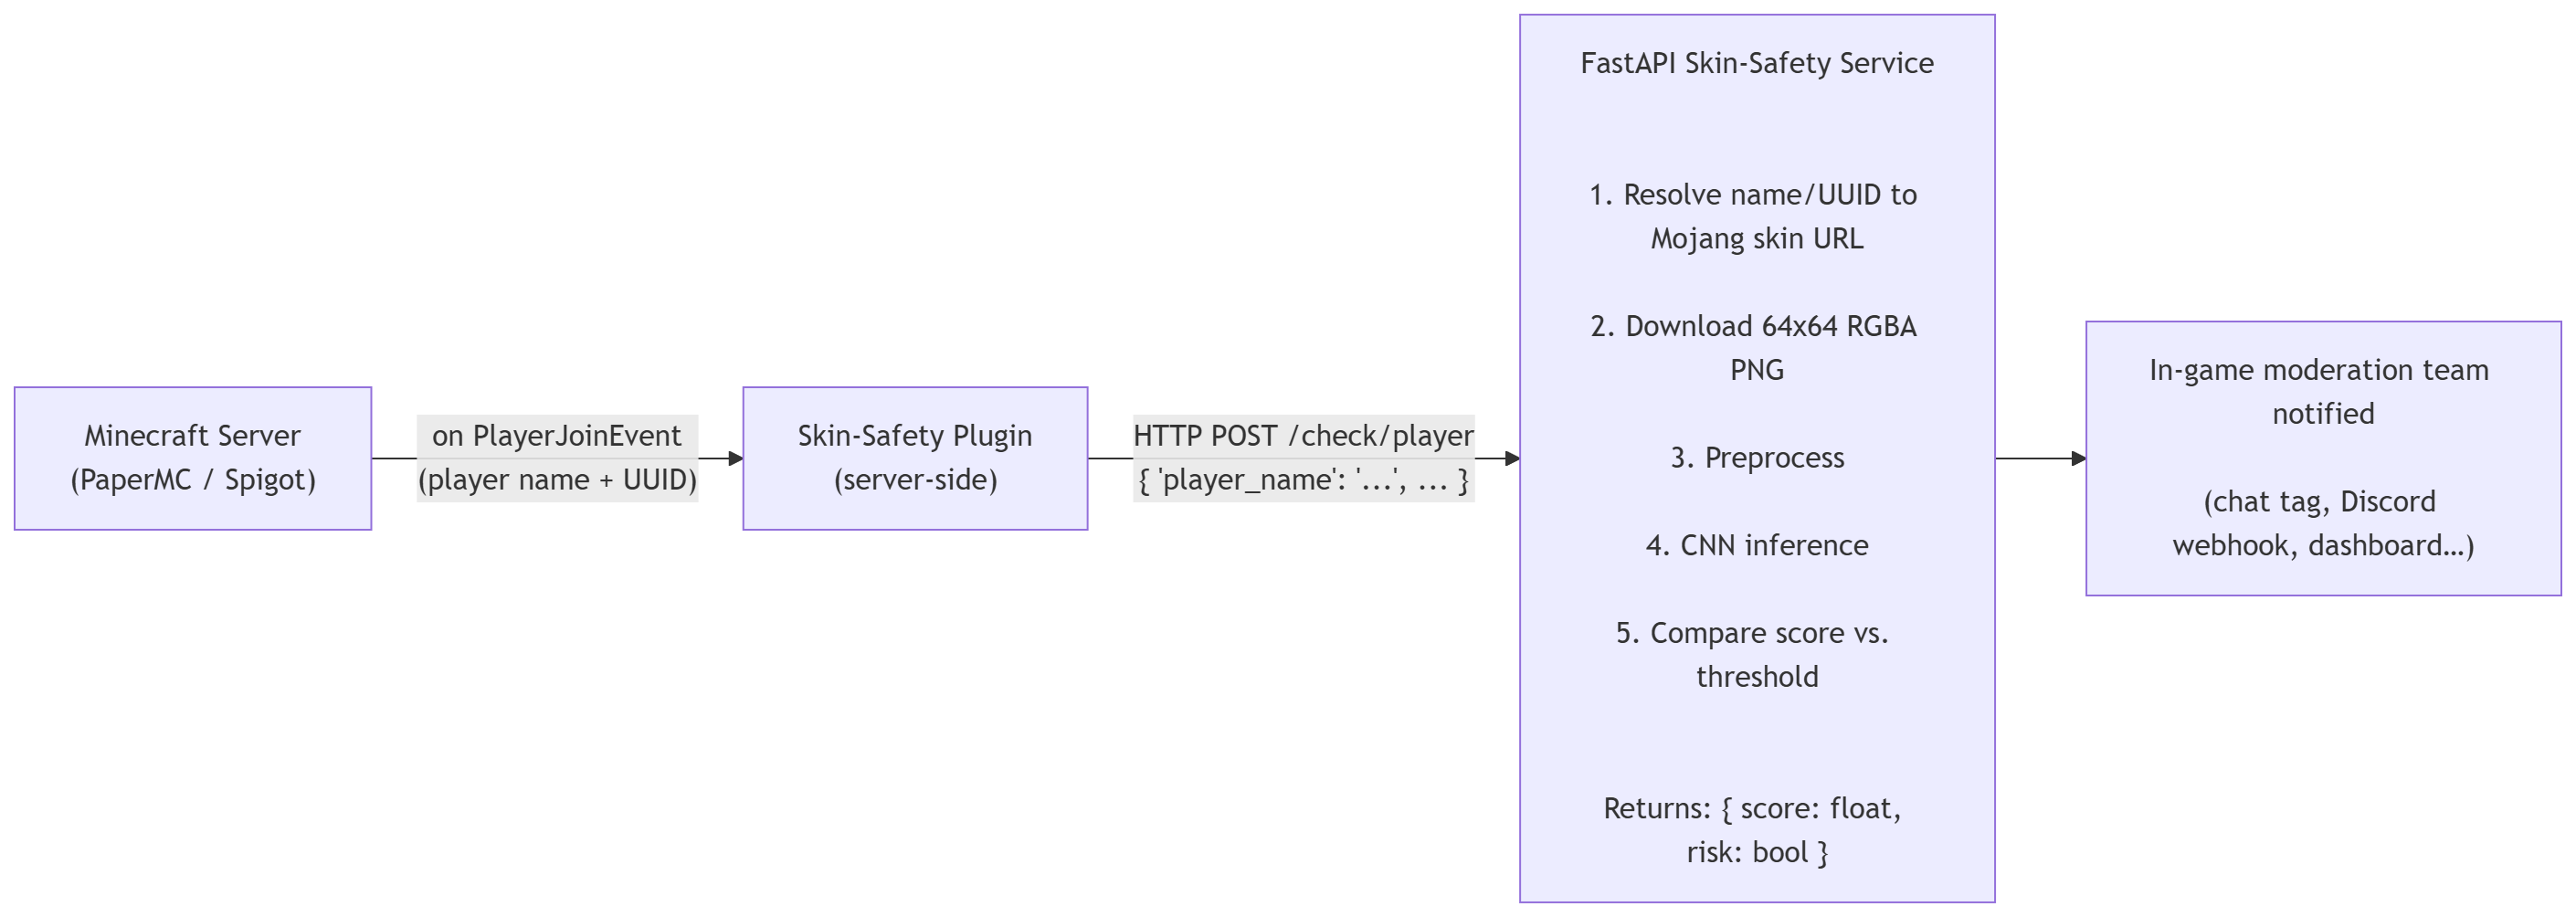

## 6.2 FastAPI

The service is implemented with **FastAPI** (`06_Deployment/api/main.py`). It exposes a single
prediction endpoint:

### `POST /check/player/`

**Request body:**

```json
{
  "player_name": "SpiderMan",
  "player_id":   "dda6ea83-75bc-4f9f-b2bd-eb5f2e6c297a"
}
```

Either `player_name` *or* `player_id` is required. If both are given, `player_id` (UUID) takes
precedence, it is the more stable identifier and avoids a name-to-UUID lookup.

**Response body:**

```json
{
  "player_name": "SpiderMan",
  "player_id":   "dda6ea83-75bc-4f9f-b2bd-eb5f2e6c297a",
  "score":       0.823,
  "risk":        true
}
```

- `score`: raw CNN probability for class 1 (prohibited), in `[0, 1]`.
- `risk`: boolean, `score > threshold`. The threshold is configured server-side at deploy time.

**Error responses:**

- `400` if both `player_name` and `player_id` are empty.
- (Future) `502` if the Mojang API is unreachable or returns no skin.


---

## 6.3 Skin fetching

`06_Deployment/api/minecraft_skin_downloader.py` resolves a player to their current skin PNG
using the official Mojang API:

1. `player_name` → `GET https://api.mojang.com/users/profiles/minecraft/{name}` → UUID.
2. `UUID` → `GET https://sessionserver.mojang.com/session/minecraft/profile/{uuid}` → base64
   profile blob containing a skin URL.
3. Download the URL and persist to `./data/skins/<scope>/<id>.png`.

Notes:

- This is the **same Mojang API path** that we abandoned for bulk dataset collection in CRISP Phase 2 because of
  rate limits. At deployment time the rate limit is irrelevant (~50-100 requests per minute)
  one request per joining player.
- For a production deployment this should be wrapped in a small cache keyed on `(uuid, skin_hash)`
  so that fast repeated joins by the same player do not refetch and re-classify the same skin.

## 6.4 The threshold is an important business factor

The decision threshold is **not** a property of the model — it is a property of the policy
the server admin wants to enforce.

From the Evaluation notebook, the threshold tuned on the validation set for a recall target of
0.95 is **0.652**. A stricter operating point (e.g. recall ≥ 0.80, fewer false alarms) would
choose a higher threshold; a looser one would choose a lower threshold. The full recall /
precision / F1 sweep is available in the Evaluation notebook for any admin to inspect.

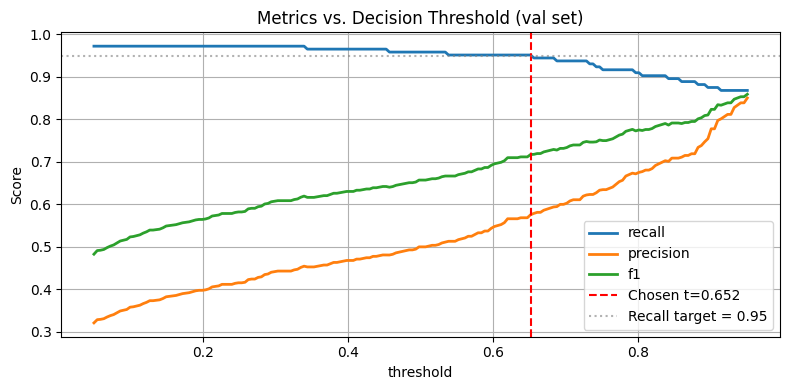

In `main.py` the threshold is declared as a single module-level constant:

```python
model_threshold = 0.652
```

For a real deployment this would become an environment variable or a config file, and ideally
each Minecraft server operator would tune it on a small set of their own examples.

---
## 6.5 Running the service locally

```powershell
# from the project root
cd 06_Deployment\api
uvicorn main:app --reload --host 0.0.0.0 --port 8000
```

Smoke-test with `curl` or Postman:

```powershell
curl -X POST http://localhost:8000/check/player/ `
     -H "Content-Type: application/json" `
     -d '{"player_name": "Notch"}'
```

The service has been tested locally end-to-end against real Mojang player names via Postman.



## 6.6 Limitations and not-yet-done

The deployment artifact is a **functional proof of concept**, not a production service. Items
that would need to be addressed before going live on a real Minecraft server network:

| Area | Current state | What would be needed for production |
|---|---|---|
| **Authentication** | None — endpoint is public | API keys per server operator, rate limiting per key |
| **Input validation** | Minimal — empty-string check only | Strict UUID regex, length limits, content-type enforcement |
| **Skin caching** | None — every call re-downloads + re-infers | Cache by skin hash; only re-infer when the player's skin actually changes |
| **Concurrency** | Default Uvicorn worker | Multiple workers + a load balancer; batch inference within a small window |
| **Observability** | `print(...)` to stdout | Structured logs, metrics (latency, score distribution), traces |
| **Model management** | Single hard-coded `.keras` file in the repo | Model registry; versioned deployments; canary roll-outs |
| **Real prohibited classes** | Spider-Man proxy only | Retrain on actual banned-player data per server operator (see future work in README) |


## 6.7 Summary

- The CNN ships as a stateless FastAPI service that takes a player name/UUID and returns a
  risk score plus a boolean flag.
- A Spigot/PaperMC plugin would call this service on `PlayerJoinEvent` and surface flagged
  players to the human moderation team in-game.
- The decision threshold is a **deployment-time policy parameter** tuned to a server's
  recall / precision preference. The model itself is unchanged across deployments.
- The current implementation is a functional proof of concept; remaining work is standard
  production-ML hardening, not algorithmic.
